<a href="https://colab.research.google.com/github/derekwang8/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. GLMs let us model outcomes that are not well-suited to ordinary linear regression, especially binary or categorical outcomes.
The activation/link function maps the linear predictor into a sensible range, such as probabilities between 0 and 1.
This is an advantage over plain linear models because linear regression can produce impossible predictions like negative probabilities.

2. These losses match the probabilistic model used by logistic regression.
They heavily penalize confident wrong predictions and reward assigning high probability to the correct class.
Minimizing cross entropy is the same as maximizing likelihood under the model.

3. True, in the sense that it is linear in the predictors on the log-odds scale:
log(p / (1 - p)) = b0 + b1x1 + ... + bkxk.
It is not linear in the predicted probability itself.

4. False.
It is one of the standard classification models.
It predicts class probabilities, and those probabilities can be converted into class labels.

5. Not directly in probability space.
A coefficient gives the change in the log-odds for a 1-unit increase in that feature, holding other variables fixed.

6. False.
Logistic regression is linear in the features on the log-odds scale, so feature engineering can still matter a lot.
Interactions, nonlinear terms, and transformations may improve fit.

7. False.
Logistic regression is better for binary outcomes, but not for every task.
Model choice depends on the outcome type and the goal of the analysis.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Missing values before handling:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64 

Rows after dropping missing values: 4424

Q2.2 Logistic regression coefficients


,feature,coefficient
0,Debtor,0.530625
3,Age at enrollment,0.049925
2,Scholarship holder,-1.227442
1,Tuition fees up to date,-2.556542



Interpretation:
- Debtor: predicts a higher dropout probability
- Age at enrollment: predicts a higher dropout probability
- Scholarship holder: predicts a lower dropout probability
- Tuition fees up to date: predicts a lower dropout probability

Does being up to date on tuition reduce dropout risk? Yes


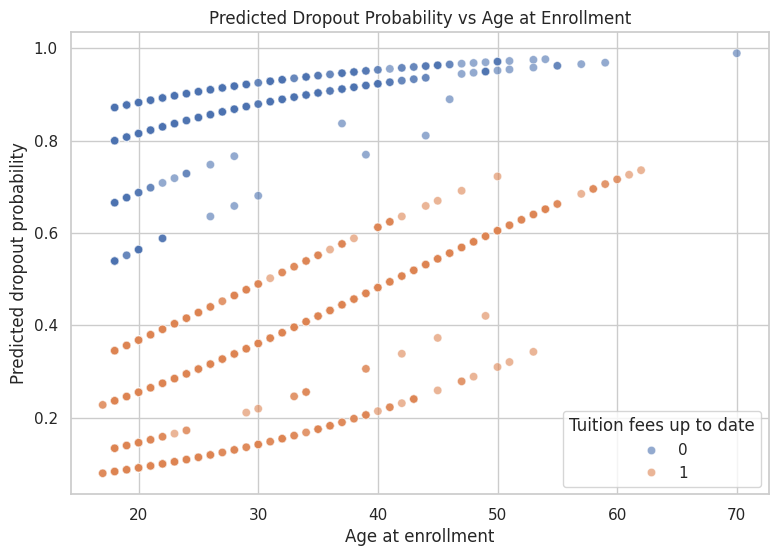


Ages where being up to date on tuition reduces dropout the most:


,tuition_effect_on_dropout
Age at enrollment,
22,-0.537499
23,-0.535802
21,-0.535541
20,-0.532669
24,-0.531446
19,-0.529255
25,-0.527728
26,-0.527287
18,-0.525951


Average change in predicted dropout probability from being up to date on tuition: -0.5162

Confusion matrix (rows=true, cols=predicted):
[[2841  162]
 [ 891  530]]

Accuracy: 0.7620


In [3]:
data_path = "/content/data.csv"
df = pd.read_csv(data_path, sep=";")

q2_cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target",
]
q2 = df[q2_cols].copy()

print("Missing values before handling:")
print(q2.isna().sum(), "\n")

q2_bin = q2.copy()
q2_bin["dropout"] = (q2_bin["Target"] == "Dropout").astype(int)

q2_bin = q2_bin.dropna().copy()
print(f"Rows after dropping missing values: {len(q2_bin)}")

X = q2_bin[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = q2_bin["dropout"]

logit_q2 = LogisticRegression(max_iter=5000)
logit_q2.fit(X, y)

coef_table_q2 = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logit_q2.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nQ2.2 Logistic regression coefficients")
display(coef_table_q2)

print("\nInterpretation:")
for _, row in coef_table_q2.iterrows():
    direction = "higher" if row["coefficient"] > 0 else "lower"
    print(f"- {row['feature']}: predicts a {direction} dropout probability")

tuition_coef = coef_table_q2.loc[
    coef_table_q2["feature"] == "Tuition fees up to date", "coefficient"
].iloc[0]
print(f"\nDoes being up to date on tuition reduce dropout risk? {'Yes' if tuition_coef < 0 else 'No'}")

q2_bin["pred_prob_dropout"] = logit_q2.predict_proba(X)[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=q2_bin,
    x="Age at enrollment",
    y="pred_prob_dropout",
    hue="Tuition fees up to date",
    alpha=0.6,
)
plt.title("Predicted Dropout Probability vs Age at Enrollment")
plt.ylabel("Predicted dropout probability")
plt.show()

X_tuition_1 = X.copy()
X_tuition_1["Tuition fees up to date"] = 1

X_tuition_0 = X.copy()
X_tuition_0["Tuition fees up to date"] = 0

p_tuition_1 = logit_q2.predict_proba(X_tuition_1)[:, 1]
p_tuition_0 = logit_q2.predict_proba(X_tuition_0)[:, 1]
tuition_effect = p_tuition_1 - p_tuition_0

q2_bin["tuition_effect_on_dropout"] = tuition_effect

age_effect = (
    q2_bin.groupby("Age at enrollment")["tuition_effect_on_dropout"]
    .mean()
    .sort_values()
)

print("\nAges where being up to date on tuition reduces dropout the most:")
display(age_effect.head(10))

print(f"Average change in predicted dropout probability from being up to date on tuition: {tuition_effect.mean():.4f}")

q2_bin["pred_class"] = logit_q2.predict(X)
cm_q2 = confusion_matrix(y, q2_bin["pred_class"])
acc_q2 = accuracy_score(y, q2_bin["pred_class"])

print("\nConfusion matrix (rows=true, cols=predicted):")
print(cm_q2)
print(f"\nAccuracy: {acc_q2:.4f}")

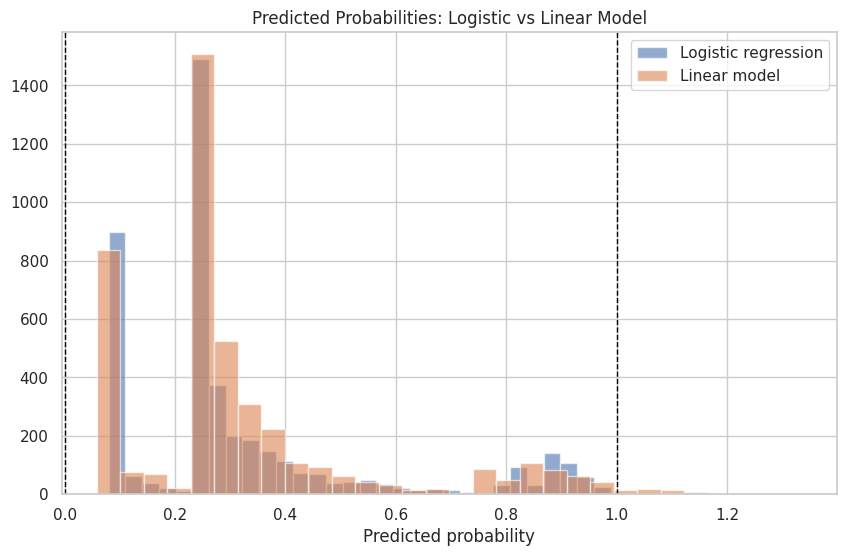

Logistic accuracy: 0.7620
Linear-model accuracy: 0.7633
Linear prediction range: [0.0583, 1.3350]
Logistic prediction range: [0.0795, 0.9891]

Comparison:
- Logistic regression is usually more appropriate because it keeps probabilities between 0 and 1.
- The linear model may sometimes have similar accuracy, but it can produce impossible probabilities below 0 or above 1.
- That makes logistic regression easier to interpret and better suited for binary outcomes.



In [4]:
lin_q2 = LinearRegression()
lin_q2.fit(X, y)

q2_bin["pred_prob_linear"] = lin_q2.predict(X)
q2_bin["pred_class_linear"] = (q2_bin["pred_prob_linear"] >= 0.5).astype(int)

acc_q2_linear = accuracy_score(y, q2_bin["pred_class_linear"])

plt.figure(figsize=(10, 6))
plt.hist(q2_bin["pred_prob_dropout"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(q2_bin["pred_prob_linear"], bins=30, alpha=0.6, label="Linear model")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.legend()
plt.title("Predicted Probabilities: Logistic vs Linear Model")
plt.xlabel("Predicted probability")
plt.show()

print(f"Logistic accuracy: {acc_q2:.4f}")
print(f"Linear-model accuracy: {acc_q2_linear:.4f}")
print(f"Linear prediction range: [{q2_bin['pred_prob_linear'].min():.4f}, {q2_bin['pred_prob_linear'].max():.4f}]")
print(f"Logistic prediction range: [{q2_bin['pred_prob_dropout'].min():.4f}, {q2_bin['pred_prob_dropout'].max():.4f}]")

print("""
Comparison:
- Logistic regression is usually more appropriate because it keeps probabilities between 0 and 1.
- The linear model may sometimes have similar accuracy, but it can produce impossible probabilities below 0 or above 1.
- That makes logistic regression easier to interpret and better suited for binary outcomes.
""")

In [5]:
risk_summary = q2_bin.sort_values("pred_prob_dropout", ascending=False)[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "pred_prob_dropout"
]].head(10)

print("Most at-risk students in the sample:")
display(risk_summary)

print("""
The students most at risk of dropping out are the ones with high predicted dropout probabilities.
In this model, risk tends to be higher for students who are debtors, not up to date on tuition, not scholarship holders, and older at enrollment if the age coefficient is positive.

Possible interventions:
- tuition payment plans or emergency financial aid
- debt counseling and proactive outreach
- scholarship or grant support
- academic advising and early-alert systems
- mentoring and first-semester support for students struggling to stay on track
""")

Most at-risk students in the sample:


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,pred_prob_dropout
689,1,0,0,70,0.989133
2876,1,0,0,54,0.976161
717,1,0,0,53,0.974971
1887,1,0,0,51,0.972415
3472,1,0,0,50,0.971044
678,1,0,0,50,0.971044
709,1,0,0,50,0.971044
3526,1,0,0,49,0.969607
3281,0,0,0,59,0.968668
4260,1,0,0,48,0.968100



The students most at risk of dropping out are the ones with high predicted dropout probabilities.
In this model, risk tends to be higher for students who are debtors, not up to date on tuition, not scholarship holders, and older at enrollment if the age coefficient is positive.

Possible interventions:
- tuition payment plans or emergency financial aid
- debt counseling and proactive outreach
- scholarship or grant support
- academic advising and early-alert systems
- mentoring and first-semester support for students struggling to stay on track



In [6]:
q2_multi = q2.dropna().copy()

X_multi = q2_multi[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = q2_multi["Target"]

multi_q2 = LogisticRegression(
    multi_class="multinomial",
    max_iter=5000
)
multi_q2.fit(X_multi, y_multi)

pred_multi = multi_q2.predict(X_multi)
proba_multi = multi_q2.predict_proba(X_multi)

cm_multi = confusion_matrix(y_multi, pred_multi, labels=multi_q2.classes_)
acc_multi = accuracy_score(y_multi, pred_multi)

print("Classes:", list(multi_q2.classes_))
print("\nConfusion matrix (rows=true, cols=predicted):")
display(pd.DataFrame(cm_multi, index=multi_q2.classes_, columns=multi_q2.classes_))
print(f"\nAccuracy: {acc_multi:.4f}")

proba_df = pd.DataFrame(proba_multi, columns=[f"prob_{c}" for c in multi_q2.classes_])
display(proba_df.head())

print("\nClasses predicted by hard classification:", sorted(pd.Series(pred_multi).unique().tolist()))
print("Classes appearing in predicted probabilities:", [c for c in multi_q2.classes_ if (proba_df[f'prob_{c}'] > 0).any()])

print("""
Written interpretation:
- The confusion matrix shows which classes are most often confused with one another.
- Hard classification may fail to predict some classes if one class rarely has the highest predicted probability.
- Predicted probabilities can still assign nonzero probability to every class even when the hard predictions do not.
""")

Classes: ['Dropout', 'Enrolled', 'Graduate']

Confusion matrix (rows=true, cols=predicted):


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Dropout,Enrolled,Graduate
Dropout,1054,0,367
Enrolled,280,0,514
Graduate,146,0,2063



Accuracy: 0.7046


,prob_Dropout,prob_Enrolled,prob_Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104



Classes predicted by hard classification: ['Dropout', 'Graduate']
Classes appearing in predicted probabilities: ['Dropout', 'Enrolled', 'Graduate']

Written interpretation:
- The confusion matrix shows which classes are most often confused with one another.
- Hard classification may fail to predict some classes if one class rarely has the highest predicted probability.
- Predicted probabilities can still assign nonzero probability to every class even when the hard predictions do not.



**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

Missing values before handling:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64 

Rows after dropping missing values: 312
Q3.2 Logistic regression coefficients


,feature,coefficient
2,cat__Drug_Placebo,0.231225
3,num__Bilirubin,-0.351424
0,cat__Edema_S,-0.450677
1,cat__Edema_Y,-1.611049



Interpretation guide:
- Positive coefficient -> higher survival probability
- Negative coefficient -> lower survival probability



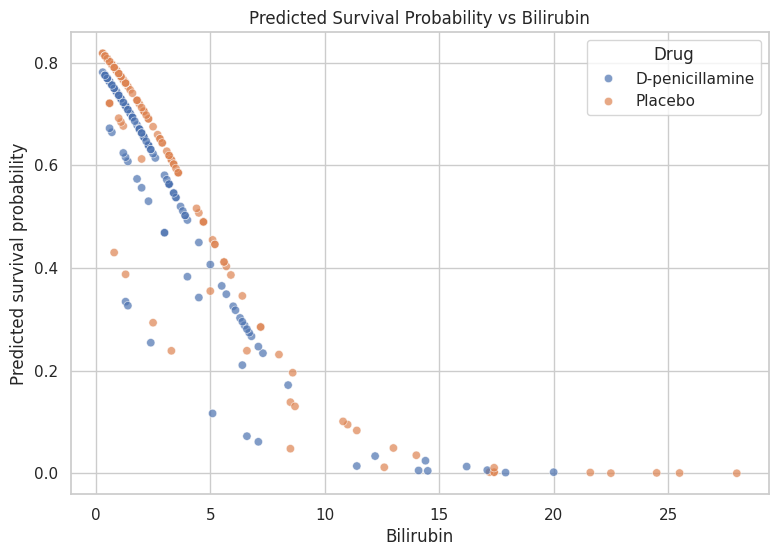

Bilirubin values where the drug increases survival the most:


,drug_effect_on_survival
bili_bin,
28,-0.000035
22,-0.000076
25,-0.000132
24,-0.000188
21,-0.000332
20,-0.000581
17,-0.000936
16,-0.003380
14,-0.003990


Average change in predicted survival probability from taking the drug: -0.0424

Confusion matrix (rows=true, cols=predicted):
[[ 59  66]
 [ 16 171]]

Accuracy: 0.7372


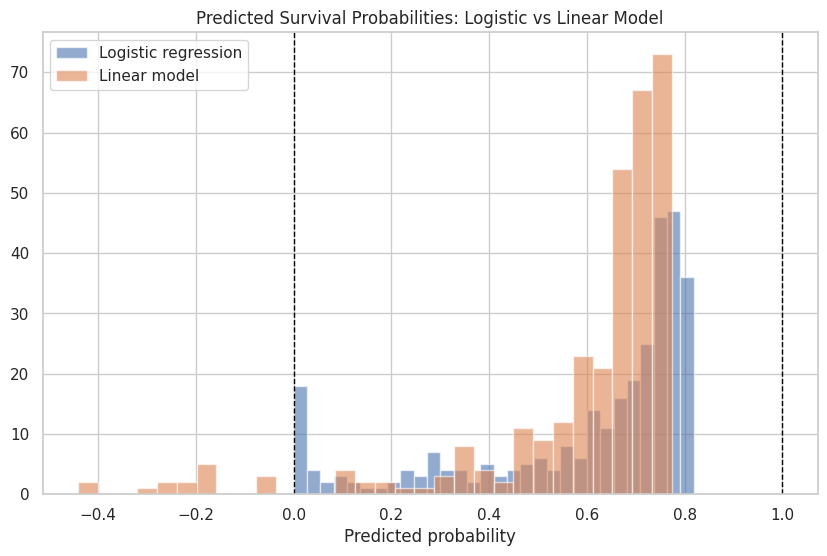

Logistic accuracy: 0.7372
Linear-model accuracy: 0.7212
Linear prediction range: [-0.4417, 0.7739]
Logistic prediction range: [0.0002, 0.8184]

Written interpretation:
- If the drug coefficient is positive, the drug is associated with better survival; if negative, worse survival.
- If the bilirubin coefficient is negative, higher bilirubin predicts lower survival.
- Edema categories with more negative coefficients indicate lower survival rates.
- Logistic regression is preferable because it constrains predictions to valid probabilities.



In [7]:
cirrhosis_path = "/content/cirrhosis.csv"
cir = pd.read_csv(cirrhosis_path)

q3_cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
cir_q3 = cir[q3_cols].copy()

print("Missing values before handling:")
print(cir_q3.isna().sum(), "\n")

cir_q3["survived"] = cir_q3["Status"].isin(["C", "CL"]).astype(int)

cir_q3 = cir_q3.dropna().copy()
print(f"Rows after dropping missing values: {len(cir_q3)}")

X3 = cir_q3[["Edema", "Drug", "Bilirubin"]]
y3 = cir_q3["survived"]

pre_q3 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Edema", "Drug"]),
        ("num", "passthrough", ["Bilirubin"]),
    ]
)

logit_q3 = Pipeline([
    ("pre", pre_q3),
    ("model", LogisticRegression(max_iter=5000))
])

logit_q3.fit(X3, y3)
cir_q3["pred_prob_survival"] = logit_q3.predict_proba(X3)[:, 1]
cir_q3["pred_class_survival"] = logit_q3.predict(X3)

feature_names_q3 = logit_q3.named_steps["pre"].get_feature_names_out()
coef_q3 = logit_q3.named_steps["model"].coef_[0]

coef_table_q3 = pd.DataFrame({
    "feature": feature_names_q3,
    "coefficient": coef_q3
}).sort_values("coefficient", ascending=False)

print("Q3.2 Logistic regression coefficients")
display(coef_table_q3)

print("""
Interpretation guide:
- Positive coefficient -> higher survival probability
- Negative coefficient -> lower survival probability
""")

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=cir_q3,
    x="Bilirubin",
    y="pred_prob_survival",
    hue="Drug",
    alpha=0.7,
)
plt.title("Predicted Survival Probability vs Bilirubin")
plt.ylabel("Predicted survival probability")
plt.show()

X3_drug = X3.copy()
X3_drug["Drug"] = "D-penicillamine"

X3_placebo = X3.copy()
X3_placebo["Drug"] = "Placebo"

p_drug = logit_q3.predict_proba(X3_drug)[:, 1]
p_placebo = logit_q3.predict_proba(X3_placebo)[:, 1]
drug_effect = p_drug - p_placebo

cir_q3["drug_effect_on_survival"] = drug_effect

bilirubin_effect = (
    cir_q3.assign(bili_bin=np.floor(cir_q3["Bilirubin"]).astype(int))
    .groupby("bili_bin")["drug_effect_on_survival"]
    .mean()
    .sort_values(ascending=False)
)

print("Bilirubin values where the drug increases survival the most:")
display(bilirubin_effect.head(10))

print(f"Average change in predicted survival probability from taking the drug: {drug_effect.mean():.4f}")

cm_q3 = confusion_matrix(y3, cir_q3["pred_class_survival"])
acc_q3 = accuracy_score(y3, cir_q3["pred_class_survival"])

print("\nConfusion matrix (rows=true, cols=predicted):")
print(cm_q3)
print(f"\nAccuracy: {acc_q3:.4f}")

lin_pre_q3 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Edema", "Drug"]),
        ("num", "passthrough", ["Bilirubin"]),
    ]
)

X3_lin = lin_pre_q3.fit_transform(X3)
lin_q3 = LinearRegression()
lin_q3.fit(X3_lin, y3)

cir_q3["pred_prob_linear"] = lin_q3.predict(X3_lin)
cir_q3["pred_class_linear"] = (cir_q3["pred_prob_linear"] >= 0.5).astype(int)

acc_q3_linear = accuracy_score(y3, cir_q3["pred_class_linear"])

plt.figure(figsize=(10, 6))
plt.hist(cir_q3["pred_prob_survival"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(cir_q3["pred_prob_linear"], bins=30, alpha=0.6, label="Linear model")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.legend()
plt.title("Predicted Survival Probabilities: Logistic vs Linear Model")
plt.xlabel("Predicted probability")
plt.show()

print(f"Logistic accuracy: {acc_q3:.4f}")
print(f"Linear-model accuracy: {acc_q3_linear:.4f}")
print(f"Linear prediction range: [{cir_q3['pred_prob_linear'].min():.4f}, {cir_q3['pred_prob_linear'].max():.4f}]")
print(f"Logistic prediction range: [{cir_q3['pred_prob_survival'].min():.4f}, {cir_q3['pred_prob_survival'].max():.4f}]")

print("""
Written interpretation:
- If the drug coefficient is positive, the drug is associated with better survival; if negative, worse survival.
- If the bilirubin coefficient is negative, higher bilirubin predicts lower survival.
- Edema categories with more negative coefficients indicate lower survival rates.
- Logistic regression is preferable because it constrains predictions to valid probabilities.
""")

In [8]:
cir_stage = cir[["Edema", "Bilirubin", "Stage"]].dropna().copy()
cir_stage["Stage"] = cir_stage["Stage"].astype(int).astype(str)

X_stage = cir_stage[["Edema", "Bilirubin"]]
y_stage = cir_stage["Stage"]

stage_model = Pipeline([
    ("pre", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Edema"]),
        ("num", "passthrough", ["Bilirubin"]),
    ])),
    ("model", LogisticRegression(multi_class="multinomial", max_iter=5000))
])

stage_model.fit(X_stage, y_stage)

pred_stage = stage_model.predict(X_stage)
proba_stage = stage_model.predict_proba(X_stage)

cm_stage = confusion_matrix(y_stage, pred_stage, labels=stage_model.named_steps["model"].classes_)
acc_stage = accuracy_score(y_stage, pred_stage)

print("Classes:", list(stage_model.named_steps["model"].classes_))
print("\nConfusion matrix (rows=true, cols=predicted):")
display(pd.DataFrame(
    cm_stage,
    index=stage_model.named_steps["model"].classes_,
    columns=stage_model.named_steps["model"].classes_
))
print(f"\nAccuracy: {acc_stage:.4f}")

stage_proba_df = pd.DataFrame(
    proba_stage,
    columns=[f"prob_stage_{c}" for c in stage_model.named_steps["model"].classes_]
)
display(stage_proba_df.head())

print("\nClasses predicted by hard classification:", sorted(pd.Series(pred_stage).unique().tolist()))
print("Classes appearing in predicted probabilities:", [
    c for c in stage_model.named_steps["model"].classes_
    if (stage_proba_df[f'prob_stage_{c}'] > 0).any()
])

print("""
Written interpretation:
- The confusion matrix shows how well the model separates disease stages.
- If hard predictions omit some stages, that means those classes rarely receive the highest predicted probability.
- Predicted probabilities can still include every stage, even if hard predictions do not.
""")

Classes: ['1', '2', '3', '4']

Confusion matrix (rows=true, cols=predicted):


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,1,2,3,4
1,0,0,20,1
2,0,0,82,10
3,0,0,130,25
4,0,0,93,51



Accuracy: 0.4393


,prob_stage_1,prob_stage_2,prob_stage_3,prob_stage_4
0,0.000469,0.051111,0.137332,0.811088
1,0.068675,0.255046,0.397581,0.278698
2,0.039844,0.139560,0.340088,0.480507
3,0.035217,0.137518,0.338843,0.488422
4,0.035049,0.243195,0.404019,0.317738



Classes predicted by hard classification: ['3', '4']
Classes appearing in predicted probabilities: ['1', '2', '3', '4']

Written interpretation:
- The confusion matrix shows how well the model separates disease stages.
- If hard predictions omit some stages, that means those classes rarely receive the highest predicted probability.
- Predicted probabilities can still include every stage, even if hard predictions do not.



**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

1. Linear model:
   y_hat = b0 + sum_k b_k x_k

   Derivative with respect to x_k:
   d(y_hat)/d(x_k) = b_k

   So a 1-unit increase in x_k changes the prediction by exactly b_k.

2. Logistic model:
   p_hat = exp(b·x) / (1 + exp(b·x))

   Let p_hat = sigma(b·x). Then:
   d(p_hat)/d(x_k) = p_hat(1 - p_hat) * b_k

   Unlike the linear model, this effect is not constant.
   It depends on the current predicted probability p_hat.
   The effect is largest when p_hat is near 0.5, because p_hat(1 - p_hat) is then near 0.25.

   So near p_hat = 0.5:
   d(p_hat)/d(x_k) ≈ 0.25 * b_k
   Equivalently, 4 * d(p_hat)/d(x_k) ≈ b_k

   That means the coefficient itself (times 1/4 in probability terms, or times 4 for the derivative-to-coefficient comparison)
   is a rough guide only when p_hat is around 0.5.

3. Log-odds interpretation:
   log(p_hat / (1 - p_hat)) = b0 + sum_k b_k x_k

   A 1-unit increase in x_k changes the log-odds by exactly b_k.

   So in logistic regression:
   - coefficients are constant effects on log-odds
   - but variable effects on predicted probability